In [7]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm 
import seaborn as sns
import math

from scipy.stats import gaussian_kde
from scipy.signal import argrelextrema

from scipy.sparse import issparse

import gc


# set figure size for better visibility
sc.settings.set_figure_params(dpi=100, frameon=False)
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)

In [8]:
## --- LOAD DATA ---
adata = sc.read_h5ad("../data/data_filtered_raw.h5ad")

## STANDARD NORMALIZATION

We start with a standard log(x+1) normalization (CPM) to apply the PCA.

In [9]:
'''
# Standar normalization (CPM - Counts Per Million)
sc.pp.normalize_total(adata, target_sum=1e4)

# Logarithmic transformation (Basic variance stabilization)
sc.pp.log1p(adata)

# Save normalized mixed data
adata.write("../data/data_standard_norm_mixed.h5ad", compression="gzip")

## --- Divide data ---
adata_gld = adata[adata.obs['experiment'] == 'gld'].copy()
adata_lncRNA = adata[adata.obs['experiment'] != 'gld'].copy()

# Save separate lncRNA and GLD data 
adata_gld.write("../data/data_standard_norm_gld.h5ad", compression="gzip")
adata_lncRNA.write("../data/data_standard_norm_lncRNA.h5ad", compression="gzip")

'''

'\n# Standar normalization (CPM - Counts Per Million)\nsc.pp.normalize_total(adata, target_sum=1e4)\n\n# Logarithmic transformation (Basic variance stabilization)\nsc.pp.log1p(adata)\n\n# Save normalized mixed data\nadata.write("../data/data_standard_norm_mixed.h5ad", compression="gzip")\n\n## --- Divide data ---\nadata_gld = adata[adata.obs[\'experiment\'] == \'gld\'].copy()\nadata_lncRNA = adata[adata.obs[\'experiment\'] != \'gld\'].copy()\n\n# Save separate lncRNA and GLD data \nadata_gld.write("../data/data_standard_norm_gld.h5ad", compression="gzip")\nadata_lncRNA.write("../data/data_standard_norm_lncRNA.h5ad", compression="gzip")\n\n'

## REFINED NORMALIZATION

We are going implement two major improvements:

1. Traccking the cell cycle genes in order to potentially regressed out them 
2. Only consider the more variable genes + ignore the more abundants 

First an example of how it looks:

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


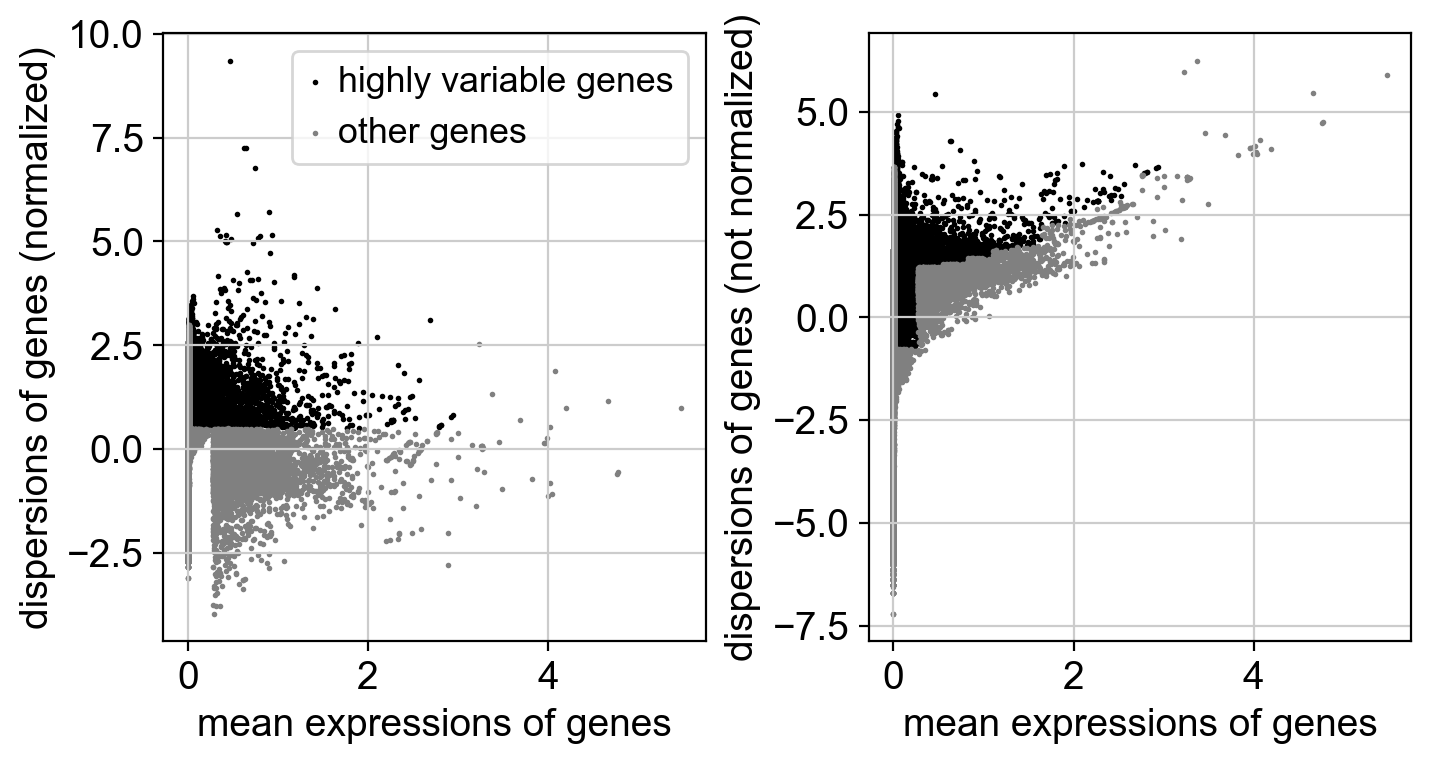

In [10]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Example how selection of variables works
sc.pp.highly_variable_genes(
    adata, 
    min_mean=0.0125, 
    max_mean=3,   # only consider genes with a mean expression between 0.0125 and 3
    min_disp=0.5, # only consider genes with a dispersion (variance/mean) above 0.5
    inplace=True
)

# Plot dispersion diagram (dispersion = variance/mean)
sc.pl.highly_variable_genes(adata)

Now work with the divided data from the beginning: necessary to select the ralative features of each experimental setup

In [ ]:
## --- LOAD DATA ---
adata = sc.read_h5ad("../data/data_filtered_raw.h5ad")

# Separate experiments 
adata_lncRNA = adata[adata.obs['experiment'] != 'gld'].copy()
adata_gld = adata[adata.obs['experiment'] == 'gld'].copy()

# CPM + Log1p
sc.pp.normalize_total(adata_lncRNA , target_sum=1e4)
sc.pp.log1p(adata_lncRNA)

sc.pp.normalize_total(adata_gld , target_sum=1e4)
sc.pp.log1p(adata_gld)

# Save raw state
adata_lncRNA.raw = adata_lncRNA.copy()
adata_gld.raw = adata_gld.copy()

# ==========================================
# FEATURE SELECTION (HVG)
# ==========================================

sc.pp.highly_variable_genes(
    adata_lncRNA, 
    min_mean=0.0125, 
    max_mean=3, 
    min_disp=0.5
)
print(f"HVGs lncRNA: {sum(adata_lncRNA.var['highly_variable'])}")


sc.pp.highly_variable_genes(
    adata_gld, 
    min_mean=0.0125, 
    max_mean=3, 
    min_disp=0.5
)
print(f"HVGs gld: {sum(adata_gld.var['highly_variable'])}")

# ==========================================
# CELL CYCLE MANAGEMENT 
# ==========================================

# A. DEFINE CELL CYCLE GENES MANUALLY (MOUSE FORMAT)
# Standard Tirosh et al. genes converted to Mouse syntax (Title Case)

s_genes_mm = [
    'Mcm5', 'Pcna', 'Tyms', 'Fen1', 'Mcm2', 'Mcm4', 'Rrm1', 'Ung', 'Gins2',
    'Mcm6', 'Cdca7', 'Dtl', 'Prim1', 'Uhrf1', 'Mlf1ip', 'Hells', 'Rfc2',
    'Rpa2', 'Nasp', 'Rad51ap1', 'Gmnn', 'Wdr76', 'Slbp', 'Ccne2', 'Ubr7',
    'Pold3', 'Msh2', 'Atad2', 'Rad51', 'Rrm2', 'Cdc45', 'Cdc6', 'Exo1',
    'Tipin', 'Dscc1', 'Blm', 'Casp8ap2', 'Usp1', 'Clspn', 'Pol1', 'Chaf1b',
    'Brip1', 'E2f8'
]

g2m_genes_mm = [
    'Hmgb2', 'Cdk1', 'Nusap1', 'Ube2c', 'Birc5', 'Tpx2', 'Top2a', 'Ndc80',
    'Cks2', 'Nuf2', 'Cks1b', 'Mki67', 'Tmpo', 'Cenpf', 'Tacc3', 'Fam64a',
    'Smc4', 'Ccnb1', 'Ckap2l', 'Ckap2', 'Aurkb', 'Bub1', 'Kif11', 'Anp32e',
    'Tubb4b', 'Gtse1', 'Kif20b', 'Hjurp', 'Cdca3', 'Hn1', 'Cdc20', 'Ttk',
    'Cdc25c', 'Kif2c', 'Rangap1', 'Ncapd2', 'Dlgap5', 'Cdca2', 'Cdca8',
    'Ect2', 'Kif23', 'Hmmr', 'Aurka', 'Psrc1', 'Anln', 'Lbr', 'Ckap5',
    'Cenpe', 'Ctcf', 'Nek2', 'G2e3', 'Gas2l3', 'Cbx5', 'Cenpa'
]

# Filter to keep only those present in your dataset
s_genes = [g for g in s_genes_mm if g in adata.var_names]
g2m_genes = [g for g in g2m_genes_mm if g in adata.var_names]

print(f"S-phase genes found: {len(s_genes)}")
print(f"G2M-phase genes found: {len(g2m_genes)}")

# B. Calculate Cycle Score
sc.tl.score_genes_cell_cycle(adata_gld, s_genes=s_genes, g2m_genes=g2m_genes)
sc.tl.score_genes_cell_cycle(adata_lncRNA, s_genes=s_genes, g2m_genes=g2m_genes)

# C. Define Blacklist
blacklist = s_genes + g2m_genes
ribo_genes = adata.var_names[adata.var_names.str.startswith(('Rps', 'Rpl'))].tolist()
mito_genes = adata.var_names[adata.var_names.str.startswith(('mt-', 'MT-'))].tolist()

full_blacklist = set(blacklist + ribo_genes + mito_genes)
print(f"Total Blacklisted genes: {len(full_blacklist)}")

# D. Apply Blacklist (Disable highly_variable flag)
for gene in full_blacklist:
    if gene in adata.var_names:
        adata_lncRNA.var.loc[gene, 'highly_variable'] = False
        adata_gld.var.loc[gene, 'highly_variable'] = False

print(f"Effective HVGs IN lncRNA: {sum(adata_lncRNA.var['highly_variable'])}")
print(f"Effective HVGs IN gld: {sum(adata_gld.var['highly_variable'])}")

# -------- Subset Matrix (HVG only) --------
adata_hvg_gld = adata_gld[:, adata_gld.var.highly_variable].copy()
adata_hvg_lncRNA = adata_lncRNA[:, adata_lncRNA.var.highly_variable].copy()

normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
HVGs lncRNA: 17457
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
HVGs gld: 13589
S-phase genes found: 41
G2M-phase genes found: 52
calculating cell cycle phase
computing score 'S_score'
    finished: added
    'S_score', score of gene set (adata.obs).
    82 total control genes are used. (0:00:00)
computing score 'G2M_score'
    finished: added
    'G2M_score', score of gene set (adata.obs).
    40 total control genes are used. (0:00:00)
-->     

## Without regressing cell cycle

In [12]:
# ==========================================
# Z-SCORE SCALING
# ==========================================

sc.pp.scale(adata_hvg_gld, max_value=10)
sc.pp.scale(adata_hvg_lncRNA, max_value=10)

# Save the normalization with Z-score, feature selection and cell cycle score
adata_hvg_gld.write("../data/data_standard_norm_gld.h5ad", compression="gzip")
adata_hvg_lncRNA.write("../data/data_standard_norm_lncRNA.h5ad", compression="gzip")

/Users/jaime/miniforge3/envs/lncRNA_ASO/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/jaime/miniforge3/envs/lncRNA_ASO/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


## Regressing out

Eliminate the correlations of the cell cycle  and the rest of gene expression (we only apply it to the HVGs)

In [13]:
## --- ORTHOGONALIZING (REGRESS OUT) ---
sc.pp.regress_out(adata_hvg_gld,['S_score', 'G2M_score'])
sc.pp.regress_out(adata_hvg_lncRNA,['S_score', 'G2M_score'])

# ==========================================
# Z-SCORE SCALING
# ==========================================

sc.pp.scale(adata_hvg_gld, max_value=10)
sc.pp.scale(adata_hvg_lncRNA, max_value=10)

# Save the normalization with Z-score, feature selection and cell cycle score
adata_hvg_gld.write("../data/data_standard_norm_regress_gld.h5ad", compression="gzip")
adata_hvg_lncRNA.write("../data/data_standard_norm_regress_lncRNA.h5ad", compression="gzip")

regressing out ['S_score', 'G2M_score']
    finished (0:00:00)
regressing out ['S_score', 'G2M_score']
    finished (0:00:00)
